---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Moving Average Models

## 1\. The Moving Average Model (MA(q))

A simple extension of the white noise model is the Moving Average model. Instead of relying solely on the current shock $a_t$, we allow the return $r_t$ to depend on the current and past shocks (or innovations).

::: {#def-ma-q}
## Moving Average Model of Order q: MA(q)
A time series $\{r_t\}$ is an MA(q) process if it can be represented as a linear combination of white noise innovations on a window of size $q$:
$$
r_t = c_0 + a_t - \theta_1 a_{t-1} - \theta_2 a_{t-2} - \dots - \theta_q a_{t-q}
$$
where $c_0$ is a constant and $\{a_t\}$ is a [white noise](autocorrelation-and-stationarity.ipynb) series with $E[a_t]=0$ and $\text{Var}(a_t)=\sigma_a^2$.
*(Note: Some texts use a plus sign instead of a minus sign for $\theta_i$, but the properties remain identical.)*
:::

## 2\. Stationarity of MA(q)

One of the most important properties of Moving Average models is that they are always weakly stationary, regardless of the values of the parameters $\theta_i$.

::: {.callout-tip collapse="true"}
## Proof of Stationarity for MA(q)
To prove weak stationarity, we must show that the mean is constant and the autocovariance depends only on the lag $\ell$.

**1. Mean:**
Taking the expectation of both sides:
$$
E[r_t] = E[c_0] + E[a_t] - \theta_1 E[a_{t-1}] - \dots - \theta_q E[a_{t-q}] = c_0 + 0 - 0 - \dots - 0 = c_0
$$
Since $c_0$ is a constant, the mean is invariant over time.

**2. Variance and Autocovariance:**
Using the independence of $a_t$ ($\text{Cov}(a_t, a_k) = 0$ for $t \ne k$):
$$
\text{Var}(r_t) = \text{Var}(a_t) + \theta_1^2 \text{Var}(a_{t-1}) + \dots + \theta_q^2 \text{Var}(a_{t-q}) = (1 + \theta_1^2 + \dots + \theta_q^2) \sigma_a^2
$$
For lag $\ell$ (where $0 < \ell \le q$):
$$
\text{Cov}(r_t, r_{t-\ell}) = E[(r_t - c_0)(r_{t-\ell} - c_0)]
$$
When we expand the product, only terms containing the same error index $a_{t-k}$ will have a non-zero expectation.
For instance, for MA(1) $r_t = c_0 + a_t - \theta_1 a_{t-1}$:
$$
\gamma_1 = E[(a_t - \theta_1 a_{t-1})(a_{t-1} - \theta_1 a_{t-2})] = -\theta_1 E[a_{t-1}^2] = -\theta_1 \sigma_a^2
$$
In general, for $\ell \le q$, $\gamma_\ell$ evaluates to a combination of $\theta$ parameters multiplied by $\sigma_a^2$.
For $\ell > q$, the time windows do not overlap at all, so:
$$
\gamma_\ell = 0 \quad \text{for} \quad \ell > q
$$
Because the mean and autocovariances do not depend on $t$, the MA(q) model is weakly stationary. $\blacksquare$
:::

## 3\. Identifying MA(q) from ACF

Because $\gamma_\ell = 0$ for $\ell > q$, the [Autocorrelation Function (ACF)](autocorrelation-and-stationarity.ipynb) of an MA(q) process **cuts off** (becomes zero) after lag $q$. 

This gives us a very clear signature to identify the hyperparameter $q$ empirically:

1. Plot the sample ACF for the empirical data.
2. Find the lag $q$ after which the ACF bars are no longer statistically significant.

### 3.1\. Ljung-Box Test

To rigorously test if a group of autocorrelations is significantly different from zero, we use the Ljung-Box test.

::: {#def-ljung-box}
## Ljung-Box Test
The Ljung-Box test evaluates the joint null hypothesis that all autocorrelations up to lag $m$ are zero (i.e., the data is independently distributed). The test statistic is:
$$
Q(m) = T(T+2) \sum_{\ell=1}^m \frac{\hat{\rho}_\ell^2}{T - \ell}
$$
Under the null hypothesis, $Q(m)$ asymptotically follows a chi-squared distribution with $m$ degrees of freedom.
:::

## 4\. Estimation (MLE)

To estimate the parameters of an MA(q) model from observations $r_1, \dots, r_T$, we typically use Maximum Likelihood Estimation (MLE). Because the model depends on unobserved past errors $a_0, a_{-1}, \dots, a_{1-q}$, two methods exist:

1. **Conditional MLE:** We assume the initial errors are zero ($a_0 = a_{-1} = \dots = a_{1-q} = 0$). This simplifies the likelihood function significantly and makes it easy to compute.
2. **Exact MLE:** Treats the initial errors as unknown random variables and estimates them alongside the model parameters. This is mathematically more complex but more robust for short time series.




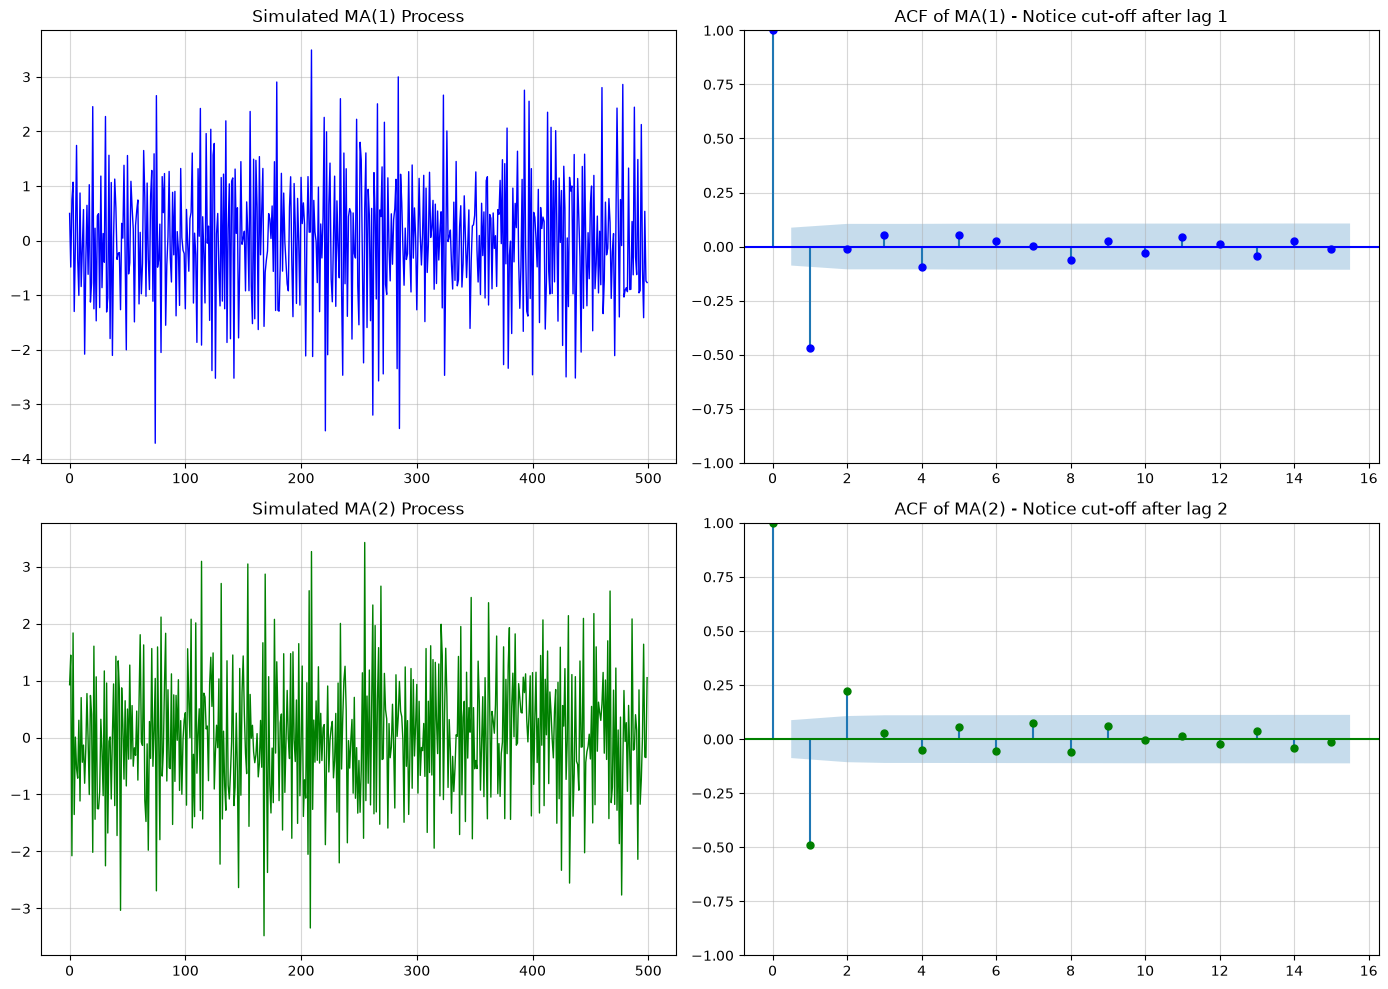

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf

# Simulate MA(1) and MA(2) processes
# Note: ArmaProcess uses the opposite sign convention (y_t = a_t + theta * a_{t-1}),
# so we pass positive values to match our minus sign convention implicitly.
np.random.seed(42)

# MA(1): r_t = a_t - 0.7 * a_{t-1} (so theta_1 = 0.7)
ma1 = ArmaProcess(ar=[1], ma=[1, -0.7])
y_ma1 = ma1.generate_sample(nsample=500)

# MA(2): r_t = a_t - 0.5 * a_{t-1} + 0.3 * a_{t-2}
ma2 = ArmaProcess(ar=[1], ma=[1, -0.5, 0.3])
y_ma2 = ma2.generate_sample(nsample=500)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MA(1) Plots
axes[0, 0].plot(y_ma1, color='blue', linewidth=1)
axes[0, 0].set_title("Simulated MA(1) Process")
axes[0, 0].grid(True, alpha=0.5)

plot_acf(y_ma1, ax=axes[0, 1], lags=15, color='blue')
axes[0, 1].set_title("ACF of MA(1) - Notice cut-off after lag 1")
axes[0, 1].grid(True, alpha=0.5)

# MA(2) Plots
axes[1, 0].plot(y_ma2, color='green', linewidth=1)
axes[1, 0].set_title("Simulated MA(2) Process")
axes[1, 0].grid(True, alpha=0.5)

plot_acf(y_ma2, ax=axes[1, 1], lags=15, color='green')
axes[1, 1].set_title("ACF of MA(2) - Notice cut-off after lag 2")
axes[1, 1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


> **References &> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay. Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.